In [2]:
import os
os.environ["OMP_NUM_THREADS"] = "3"

In [3]:
import pandas as pd
import numpy as np 
import sqlite3 
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve,
) 

In [73]:
github_raw_url = "https://raw.githubusercontent.com/amankharwal/Website-data/master/heart.csv"
df_heart = pd.read_csv(github_raw_url)

In [7]:
df_heart = pd.read_csv("C:\\Users\\DELL\\Downloads\\TS_academy data science\\Capstone\heart.csv")

In [8]:
df_heart.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [9]:
df_heart.shape

(918, 12)

In [10]:
df_heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [11]:
df_heart.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


# Push to SQL  

In [12]:
conn = sqlite3.connect("heart.db")

In [13]:
df_heart.to_sql("heart", conn, if_exists="replace", index=False)

918

### Total number of people with heart disease

In [14]:
pd.read_sql_query(
    """
    SELECT HeartDisease, COUNT(*) AS Count FROM heart
    GROUP BY HeartDisease;""", conn
)

,HeartDisease,Count
0,0,410
1,1,508


### Group people with heart diseases by age group

In [15]:
pd.read_sql_query("""
    SELECT
        CASE  
            WHEN Age < 31 THEN '1-30'
            WHEN Age BETWEEN 31 AND 50 THEN '31-50'
            ELSE '> 50'
        END AS Age_group,
        SUM(HeartDisease) AS heart_disease_count 
    FROM heart
    GROUP BY Age_group;
""", conn)

,Age_group,heart_disease_count
0,1-30,0
1,31-50,125
2,> 50,383


### The average blood pressure by gender

In [16]:
pd.read_sql_query("""
    SELECT Sex, AVG(RestingBP) AS Avg_BP FROM heart
    GROUP BY Sex;
    """, conn
)

,Sex,Avg_BP
0,F,132.212435
1,M,132.445517


### Initial exploratory data analysis

In [17]:
df_heart.shape

(918, 12)

In [18]:
df_heart.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [19]:
heart_disease = df_heart["HeartDisease"] == 1
no_heart_disease = df_heart["HeartDisease"] == 0

In [20]:
print (sum(heart_disease))
print (sum(no_heart_disease))

508
410


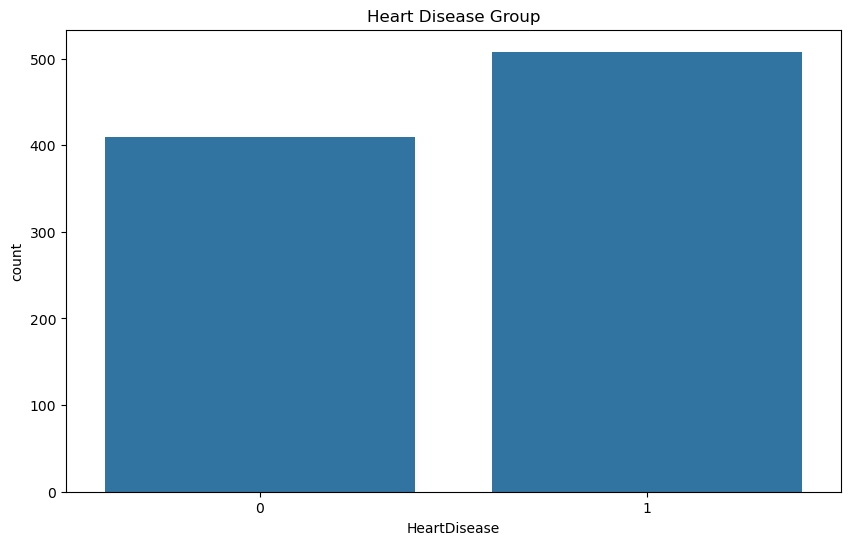

In [21]:
plt.figure(figsize = (10, 6))
sns.countplot(x = "HeartDisease", data = df_heart)
plt.title("Heart Disease Group")
plt.show()

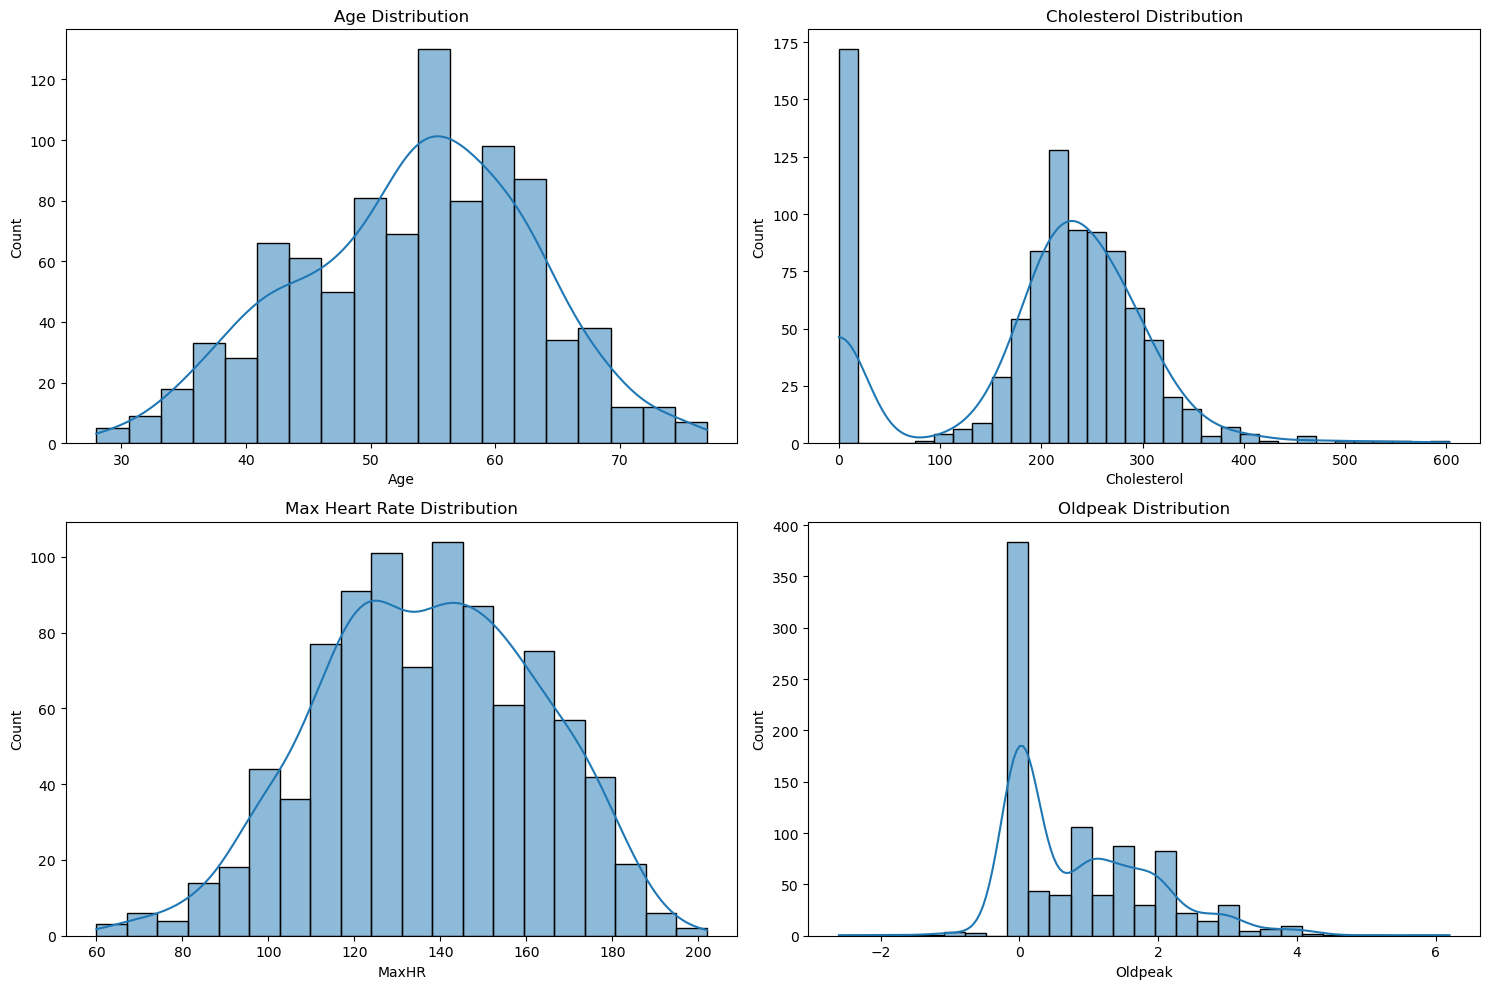

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.histplot(df_heart["Age"], ax=axes[0,0], kde=True)
axes[0,0].set_title("Age Distribution")

sns.histplot(df_heart["Cholesterol"], ax=axes[0,1], kde=True)
axes[0,1].set_title("Cholesterol Distribution")

sns.histplot(df_heart["MaxHR"], ax=axes[1,0], kde=True)
axes[1,0].set_title("Max Heart Rate Distribution")

sns.histplot(df_heart["Oldpeak"], ax=axes[1,1], kde=True)
axes[1,1].set_title("Oldpeak Distribution")

plt.tight_layout()
plt.show()

Age: roughly bell shaped, most patients are between 50 and 65. Slightly skewed right meaning there are more older patients than younger ones in this dataset.

Cholesterol:  Cholesterol cannot be 0 in a living person, those are missing values that were recorded as 0. Around 170 patients have this. This must be handled in your cleaning step.

MaxHR: it's actually slightly left skewed, meaning most patients achieved a relatively high heart rate but a smaller group had very low readings. Those low values around 60-80 are worth noting as potential outliers.

Oldpeak: heavily skewed right with most values clustering at 0 and a long tail of high values. The negative values on the left are also worth flagging.

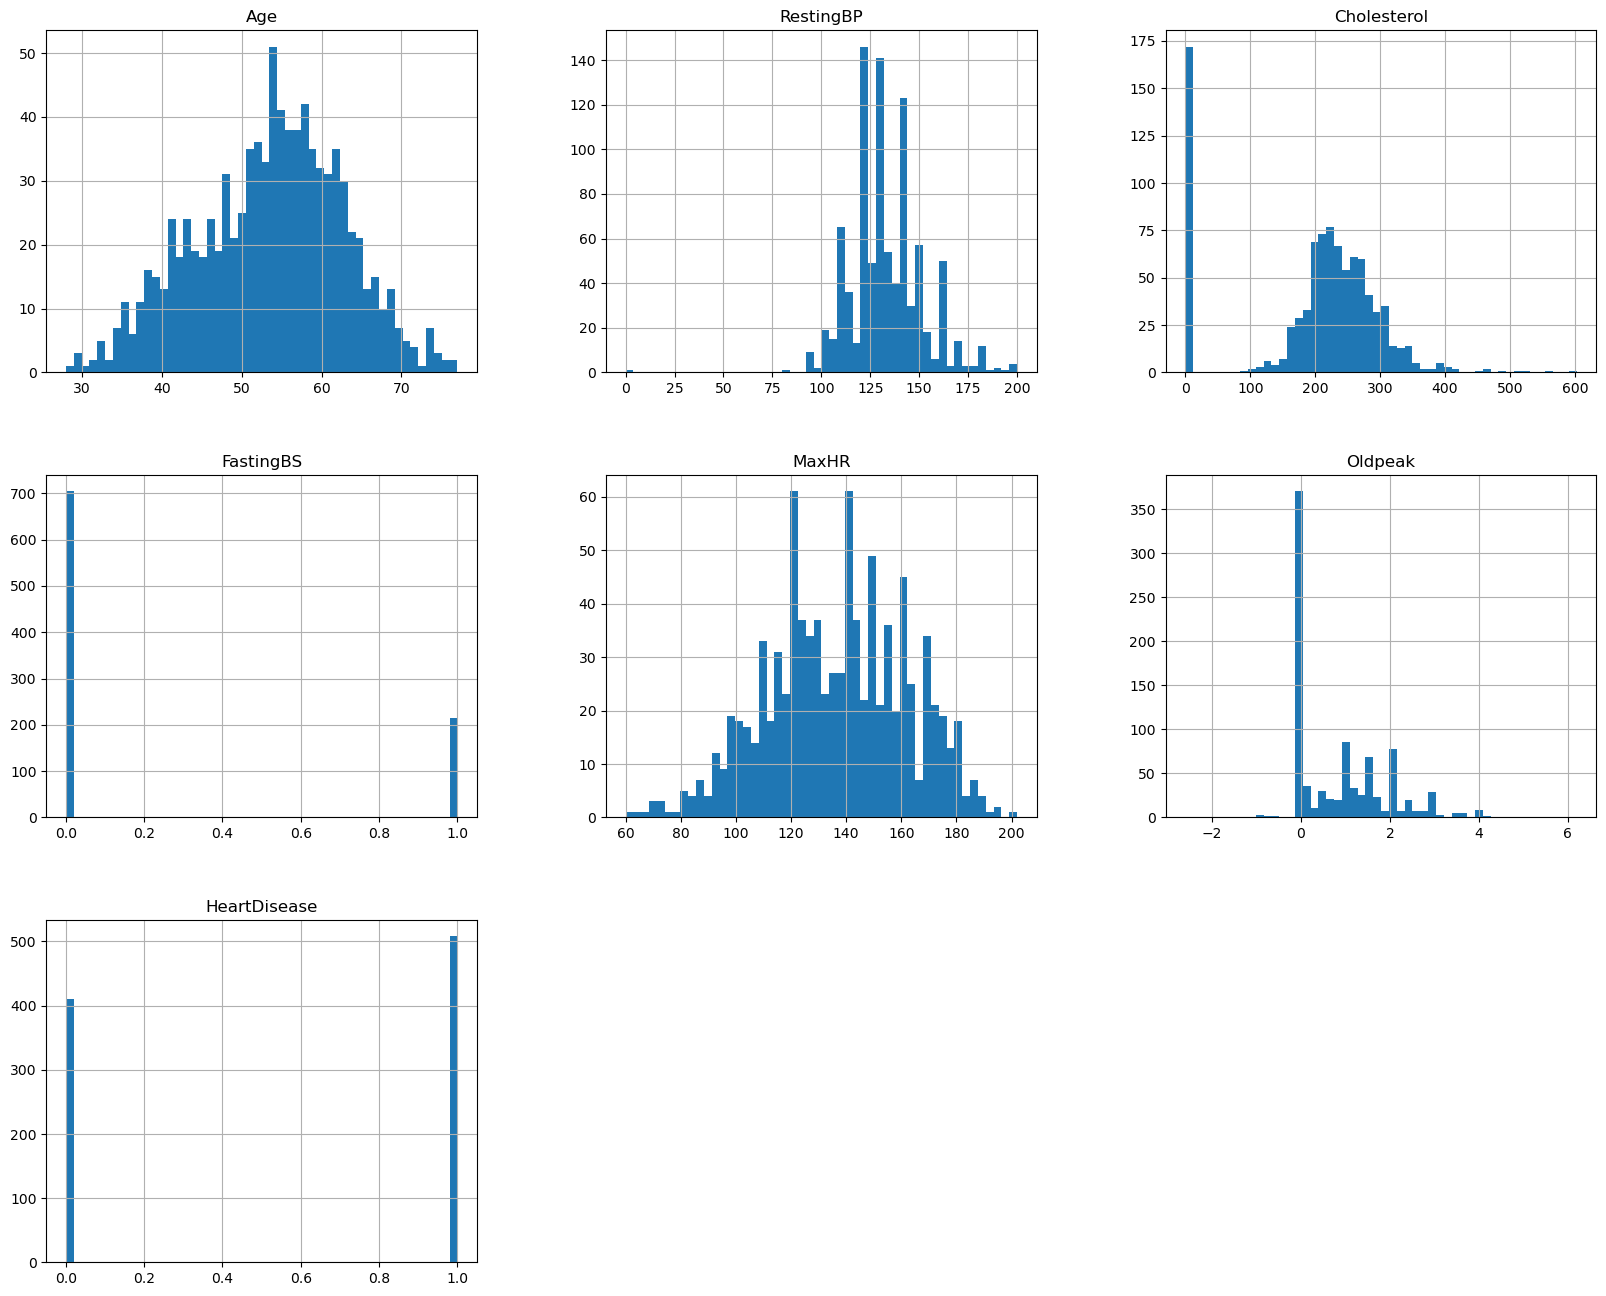

In [28]:
%matplotlib inline
df_heart.hist(bins=50, figsize=(20,16))
plt.show()

## Feature Engineering

Medical research shows heart disease risk jumps after 55, so these bins have real clinical backing 

In [29]:
df_heart["age_group"] = pd.cut(
    df_heart["Age"],
    bins=[0, 30, 60, 120],
    labels=["young", "middle", "old"])

In [30]:
df_heart["age_group"].value_counts()

age_group
middle    692
old       221
young       5
Name: count, dtype: int64

In [31]:
print((df_heart["age_group"] == 0).sum())

0


If both chestpain type and pain when excercising are high then there is an alarming problem

In [32]:
df_heart["high_chestpain"] = ((df_heart["ExerciseAngina"] == "Y") & (df_heart["ChestPainType"] == "ASY")).astype(int)
df_heart.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,age_group,high_chestpain
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0,middle,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1,middle,0
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0,middle,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1,middle,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0,middle,0


Investigation revealed cholesterol zeros are concentrated in middle and older age groups with no young patients affected. Replacement was performed using the median grouped by Sex, as cholesterol differs significantly between males and females. Grouping further by age was avoided as it would produce unreliably small group sizes. ###

In [33]:
#median_chol = df_heart[df_heart["Cholesterol"] !=0]["Cholesterol"].median()
#df_heart["Cholesterol"] = df_heart["Cholesterol"].replace(0, median_chol)

df_heart[df_heart["Cholesterol"] == 0]["Sex"].value_counts()
df_heart[df_heart["Cholesterol"] == 0]["age_group"].value_counts()

age_group
middle    111
old        61
young       0
Name: count, dtype: int64

In [34]:
df_heart["Cholesterol"] = df_heart.groupby("Sex")["Cholesterol"].transform(
    lambda x: x.replace(0, x[x != 0].median())
)

In [35]:
print((df_heart["Cholesterol"] == 0).sum())

0


This captures cardiovascular efficiency i.e how high your heart rate can go relative to your resting blood pressure,low MaxHR plus high RestingBP has a potential problem

In [36]:
median_bp = df_heart[df_heart["RestingBP"] != 0]["RestingBP"].median()
df_heart["RestingBP"] = df_heart["RestingBP"].replace(0, median_bp)

In [37]:
print((df_heart["RestingBP"] == 0).sum())
print((df_heart["Cholesterol"] == 0).sum())

0
0


In [38]:
df_heart["HR_BP_ratio"] = df_heart["MaxHR"] / df_heart["RestingBP"]
df_heart.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,age_group,high_chestpain,HR_BP_ratio
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0,middle,0,1.228571
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1,middle,0,0.975000
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0,middle,0,0.753846
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1,middle,1,0.782609
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0,middle,0,0.813333
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0,middle,0,1.416667
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0,middle,0,1.307692
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0,middle,0,1.290909
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1,middle,1,0.928571
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0,middle,0,1.000000


In [53]:
df_heart.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
age_group         0
high_chestpain    0
HR_BP_ratio       0
dtype: int64

## Feature Encoding

In [43]:
df_heart.select_dtypes(include=["object", "category"]).columns.tolist()

['Sex',
 'ChestPainType',
 'RestingECG',
 'ExerciseAngina',
 'ST_Slope',
 'age_group']

In [44]:
df_heart_encoded = pd.get_dummies(df_heart, columns = ["Sex", "ExerciseAngina", "ChestPainType", "RestingECG", "ST_Slope", "age_group"], drop_first = True)

In [45]:
print(df_heart_encoded.select_dtypes(include="object").columns.tolist())

[]


In [51]:
print(df_heart_encoded.select_dtypes(include="category").columns.tolist())

[]


In [46]:
df_heart_encoded.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,high_chestpain,HR_BP_ratio,Sex_M,ExerciseAngina_Y,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up,age_group_middle,age_group_old
0,40,140,289,0,172,0.0,0,0,1.228571,True,False,True,False,False,True,False,False,True,True,False
1,49,160,180,0,156,1.0,1,0,0.975000,False,False,False,True,False,True,False,True,False,True,False
2,37,130,283,0,98,0.0,0,0,0.753846,True,False,True,False,False,False,True,False,True,True,False
3,48,138,214,0,108,1.5,1,1,0.782609,False,True,False,False,False,True,False,True,False,True,False
4,54,150,195,0,122,0.0,0,0,0.813333,True,False,False,True,False,True,False,False,True,True,False


In [47]:
df_heart_encoded.shape

(918, 20)

In [48]:
df_heart_encoded.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,high_chestpain,HR_BP_ratio,Sex_M,ExerciseAngina_Y,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up,age_group_middle,age_group_old
0,40,140,289,0,172,0.0,0,0,1.228571,True,False,True,False,False,True,False,False,True,True,False
1,49,160,180,0,156,1.0,1,0,0.975000,False,False,False,True,False,True,False,True,False,True,False
2,37,130,283,0,98,0.0,0,0,0.753846,True,False,True,False,False,False,True,False,True,True,False
3,48,138,214,0,108,1.5,1,1,0.782609,False,True,False,False,False,True,False,True,False,True,False
4,54,150,195,0,122,0.0,0,0,0.813333,True,False,False,True,False,True,False,False,True,True,False


In [70]:
#Looking for correlation

corr_matrix = df_heart_encoded.corr()
corr_matrix["HeartDisease"].sort_values(ascending=False)

HeartDisease         1.000000
ST_Slope_Flat        0.554134
ExerciseAngina_Y     0.494282
high_chestpain       0.485458
Oldpeak              0.403951
Sex_M                0.305445
Age                  0.282039
FastingBS            0.267291
age_group_old        0.198362
RestingBP            0.117798
RestingECG_ST        0.102527
Cholesterol          0.071267
ChestPainType_TA    -0.054790
RestingECG_Normal   -0.091580
age_group_middle    -0.182790
ChestPainType_NAP   -0.212964
HR_BP_ratio         -0.366733
MaxHR               -0.400421
ChestPainType_ATA   -0.401924
ST_Slope_Up         -0.622164
Name: HeartDisease, dtype: float64

## Prepare for Modeling
For clustering we need to scale the features first. K-Means is distance-based, so a feature that ranges from 0 to 8000 (like TotalCharges) would completely dominate a feature that ranges from 0 to 1. We also separate the label from the features. For clustering we pretend we do not have the label, so we drop it from the feature matrix.

In [54]:
X = df_heart_encoded.drop(columns=["HeartDisease"]).astype(float)
y = df_heart_encoded["HeartDisease"].astype(int)

In [55]:
X.shape

(918, 19)

In [56]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [57]:
inertias = []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

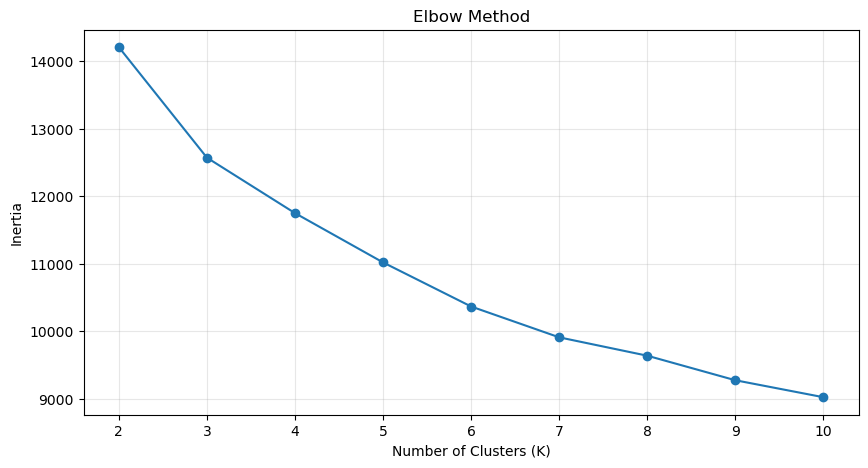

In [58]:
plt.figure(figsize=(10, 5))
plt.plot(k_range, inertias, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True, alpha=0.3)
plt.show()

In [59]:
silhouette_scores = []
k_range_sil = range(2, 11)

for k in k_range_sil:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

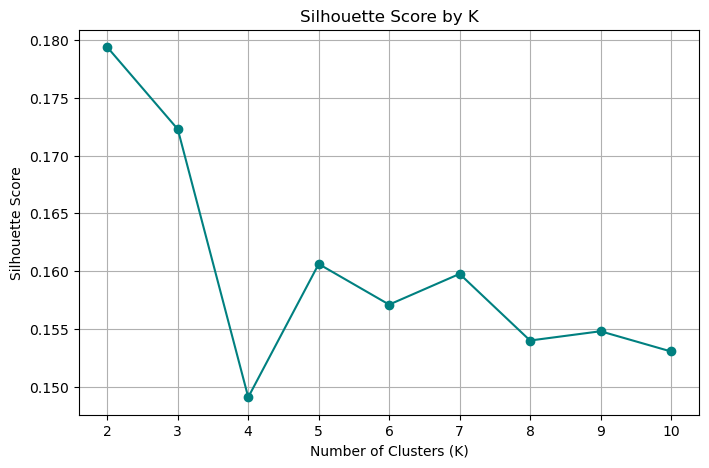

In [60]:
plt.figure(figsize=(8, 5))
plt.plot(k_range_sil, silhouette_scores, marker="o", color="teal")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by K")
plt.grid(True)
plt.show()

In [61]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

In [62]:
df_heart["kmeans_cluster"] = kmeans_labels
df_heart["kmeans_cluster"].value_counts().sort_index()

kmeans_cluster
0    382
1    219
2    317
Name: count, dtype: int64

In [63]:
# cluster names based on profiling
cluster_names = {
    0: "High Risk Middle-Aged Patients",
    1: "High Risk Elderly Patients", 
    2: "Low Risk Younger Patients"
}
df_heart["cluster_name"] = df_heart["kmeans_cluster"].map(cluster_names)

print(df_heart["cluster_name"].value_counts())

cluster_name
High Risk Middle-Aged Patients    382
Low Risk Younger Patients         317
High Risk Elderly Patients        219
Name: count, dtype: int64


In [64]:
df_heart.groupby("kmeans_cluster").agg({
    "Age": "mean",
    "Cholesterol": "mean",
    "MaxHR": "mean",
    "RestingBP": "mean",
    "Oldpeak": "mean",
    "HeartDisease": "mean"
}).round(2)

,Age,Cholesterol,MaxHR,RestingBP,Oldpeak,HeartDisease
kmeans_cluster,,,,,,
0,47.71,235.02,152.82,127.50,0.30,0.18
1,65.27,246.31,124.53,138.02,1.26,0.74
2,52.38,249.78,126.00,134.82,1.34,0.87


In [65]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

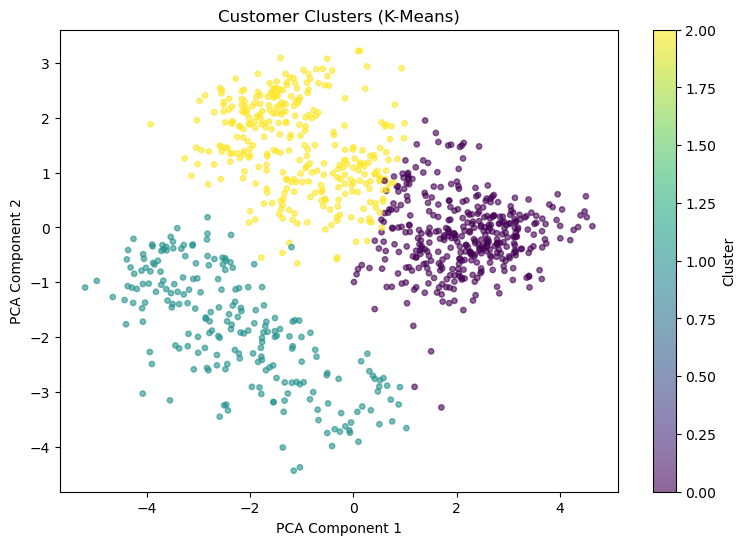

In [66]:
plt.figure(figsize=(9, 6))
plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=kmeans_labels, cmap="viridis", alpha=0.6, s=15
)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Customer Clusters (K-Means)")
plt.colorbar(label="Cluster")
plt.show()

We already have X and y from the previous section. We split them into training and testing sets, with stratification so the churn ratio is preserved in both sets.

In [67]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [68]:
y_train.value_counts(normalize=True).round(3)
y_test.value_counts(normalize=True).round(3)

HeartDisease
1    0.554
0    0.446
Name: proportion, dtype: float64

In [69]:
scaler_split = StandardScaler()
X_scaled_train = scaler_split.fit_transform(X_train)
X_scaled_test = scaler_split.transform(X_test)

In [214]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_scaled_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [215]:
y_pred_log = log_reg.predict(X_scaled_test)

In [216]:
y_proba_log = log_reg.predict_proba(X_scaled_test)[:, 1]

In [217]:
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.90      0.87      0.88        82
           1       0.90      0.92      0.91       102

    accuracy                           0.90       184
   macro avg       0.90      0.89      0.90       184
weighted avg       0.90      0.90      0.90       184



In [222]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_scaled_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,20
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [223]:
y_pred_rf = rf.predict(X_scaled_test)

In [224]:
y_proba_rf = rf.predict_proba(X_scaled_test)[:, 1]

In [225]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.84      0.82      0.83        82
           1       0.86      0.87      0.86       102

    accuracy                           0.85       184
   macro avg       0.85      0.84      0.85       184
weighted avg       0.85      0.85      0.85       184



In [226]:
rf_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False).head(10)

rf_importance

,feature,importance
17,ST_Slope_Up,0.243342
16,ST_Slope_Flat,0.170110
8,kmeans_cluster,0.129016
5,Oldpeak,0.074179
6,high_chestpain,0.071860
10,ExerciseAngina_Y,0.065324
4,MaxHR,0.048336
7,HR_BP_ratio,0.044466
0,Age,0.024584
11,ChestPainType_ATA,0.023640


In [227]:
dt = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)
dt.fit(X_scaled_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,20
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [228]:
y_pred_dt = dt.predict(X_scaled_test)

In [229]:
y_proba_dt = dt.predict_proba(X_scaled_test)[:, 1]

In [230]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.77      0.79      0.78        82
           1       0.83      0.81      0.82       102

    accuracy                           0.80       184
   macro avg       0.80      0.80      0.80       184
weighted avg       0.80      0.80      0.80       184



In [194]:
dt_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": dt.feature_importances_
}).sort_values("importance", ascending=False).head(10)

dt_importance

,feature,importance
16,ST_Slope_Up,0.634675
6,high_chestpain,0.069241
7,HR_BP_ratio,0.062685
5,Oldpeak,0.055233
1,RestingBP,0.035260
2,Cholesterol,0.033713
10,ChestPainType_NAP,0.022001
0,Age,0.018302
8,Sex_M,0.017991
4,MaxHR,0.013457


In [261]:
def evaluate_model(name, y_true, y_pred, y_proba):
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_proba),
    }

In [262]:
results = pd.DataFrame([
    evaluate_model("Logistic Regression", y_test, y_pred_log, y_proba_log),
    evaluate_model("Decision Tree", y_test, y_pred_dt, y_proba_dt),
    evaluate_model("Random Forest", y_test, y_pred_rf, y_proba_rf),
])

results.round(3)

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.897,0.895,0.922,0.908,0.931
1,Decision Tree,0.804,0.830,0.814,0.822,0.867
2,Random Forest,0.848,0.856,0.873,0.864,0.922


In [263]:
print(y_proba_log.shape)
print(y_test.head())

(184,)
356    1
763    1
817    1
735    1
892    0
Name: HeartDisease, dtype: int64


In [266]:
print(y.value_counts())
print(y.value_counts(normalize=True))

HeartDisease
1    508
0    410
Name: count, dtype: int64
HeartDisease
1    0.553377
0    0.446623
Name: proportion, dtype: float64


Dataset shows a mild 55/45 imbalance. SMOTE was skipped as the classes are sufficiently balanced. Class weights and threshold tuning were applied, lowering the threshold prioritises catching sick patients, which carries more clinical weight than a false alarm

In [267]:
rf_balanced = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)
rf_balanced.fit(X_scaled_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,20
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [268]:
y_pred_rf_bal = rf_balanced.predict(X_scaled_test)

In [269]:
y_proba_rf_bal = rf_balanced.predict_proba(X_scaled_test)[:, 1]

In [270]:
print(classification_report(y_test, y_pred_rf_bal))

              precision    recall  f1-score   support

           0       0.84      0.87      0.85        82
           1       0.89      0.86      0.88       102

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.87      0.86      0.86       184



In [271]:
thresholds = [0.5, 0.4, 0.3, 0.2]
threshold_results = []

for t in thresholds:
    y_pred_t = (y_proba_rf >= t).astype(int)
    threshold_results.append({
        "threshold": t,
        "precision": precision_score(y_test, y_pred_t),
        "recall": recall_score(y_test, y_pred_t),
        "f1": f1_score(y_test, y_pred_t),
    })

pd.DataFrame(threshold_results).round(3)

,threshold,precision,recall,f1
0,0.5,0.856,0.873,0.864
1,0.4,0.810,0.922,0.862
2,0.3,0.764,0.951,0.847
3,0.2,0.721,0.990,0.835


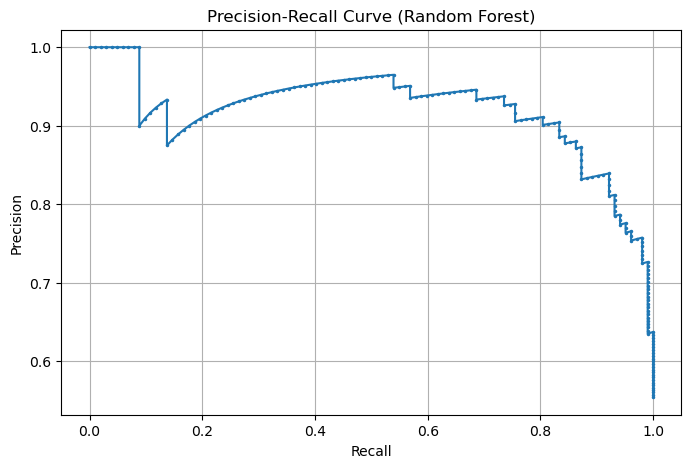

In [272]:
prec, rec, thr = precision_recall_curve(y_test, y_proba_rf)

plt.figure(figsize=(8, 5))
plt.plot(rec, prec, marker=".", markersize=3)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Random Forest)")
plt.grid(True)
plt.show()

Precision stays above 0.90 until recall hits 0.85. Threshold of 0.3 selected, in cardiac diagnosis, missing a sick patient costs more than a false alarm.

### Bonus: using SMOTE

In [273]:
!pip install imbalanced-learn -q

In [274]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", pd.Series(y_train_smote).value_counts())

Before SMOTE: HeartDisease
1    406
0    328
Name: count, dtype: int64
After SMOTE: HeartDisease
1    406
0    406
Name: count, dtype: int64


In [275]:
rf_smote = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)
rf_smote.fit(X_train_smote, y_train_smote)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,20
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [276]:
y_pred_rf_smote = rf_smote.predict(X_test)

In [277]:
y_proba_rf_smote = rf_smote.predict_proba(X_test)[:, 1]

In [278]:
print(classification_report(y_test, y_pred_rf_smote))

              precision    recall  f1-score   support

           0       0.84      0.83      0.83        82
           1       0.86      0.87      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184



Compare all models

In [281]:
y_pred_threshold = (y_proba_rf >= 0.3).astype(int)

imbalance_results = pd.DataFrame([
    evaluate_model("Baseline RF", y_test, y_pred_rf, y_proba_rf),
    evaluate_model("RF + class_weight", y_test, y_pred_rf_bal, y_proba_rf_bal),
    evaluate_model("RF + threshold 0.3", y_test, y_pred_threshold, y_proba_rf),
    evaluate_model("RF + SMOTE", y_test, y_pred_rf_smote, y_proba_rf_smote),
])

imbalance_results.round(3)

,model,accuracy,precision,recall,f1,roc_auc
0,Baseline RF,0.848,0.856,0.873,0.864,0.922
1,RF + class_weight,0.864,0.889,0.863,0.876,0.923
2,RF + threshold 0.3,0.810,0.764,0.951,0.847,0.922
3,RF + SMOTE,0.853,0.864,0.873,0.868,0.926


Threshold tuning at 0.3 is recommended as the final operating point. In cardiac diagnosis missing a sick patient is far more dangerous than a false alarm. Threshold 0.3 maximises recall while keeping precision acceptable. SMOTE and class weights improved balance but threshold tuning directly controls the clinical tradeoff between sensitivity and specificit.

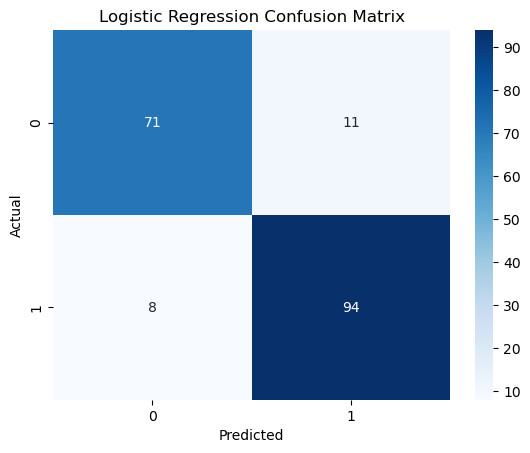

In [231]:
# Logistic Regression Confusion matrix
cm_log = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

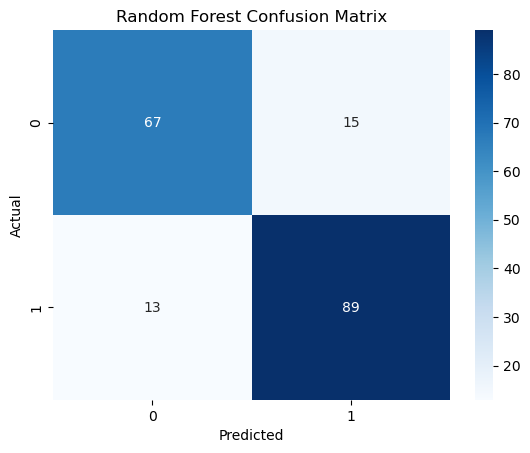

In [232]:
# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

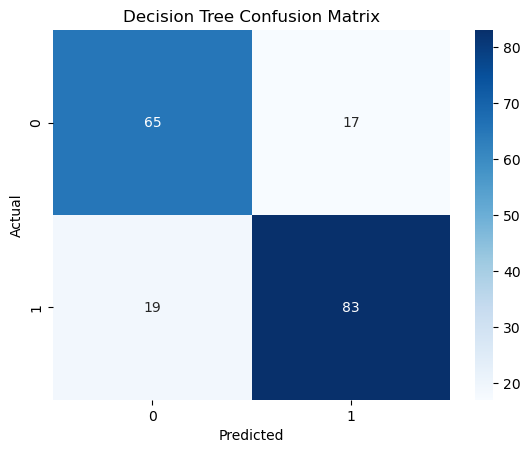

In [233]:
# Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Blues")
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [241]:
#calling labels back to encoded data
df_heart_encoded["kmeans_cluster"] = kmeans_labels

# Compute heart disease rate per cluster
cluster_churn_rate = df_heart_encoded.groupby("kmeans_cluster")["HeartDisease"].mean().round(3)
print(cluster_churn_rate)

kmeans_cluster
0    0.874
1    0.735
2    0.183
Name: HeartDisease, dtype: float64


In [249]:
cluster_heart_rate = df_heart.groupby("cluster_name")["HeartDisease"].mean().round(3)
print(cluster_heart_rate)

cluster_name
High Risk Elderly Patients        0.735
High Risk Middle-Aged Patients    0.874
Low Risk Younger Patients         0.183
Name: HeartDisease, dtype: float64


Clusters strongly aligned with heart disease outcomes. Middle-aged patients showed the highest risk at 87.4%, higher than elderly patients at 73.5%, suggesting mid-life is the most dangerous window. Younger patients were largely healthy at 18.3%, confirming Age, MaxHR and Oldpeak as the strongest risk separators. Middle-aged patients are actually higher risk than elderly ones.